# CC 311 Econometrics — Unit 5 — Lecture 3
## Cointegration & Error Correction Mechanism (ECM)

**Learning sequence:** Non-stationarity → Spurious regression → Cointegration → Long-run equilibrium → Engle–Granger → ECM

This notebook was designed to run live alongside the Lecture 3 PPT.

### Learning objectives
- Distinguish unrelated non-stationary series from cointegrated series.
- Understand why the residual is central to cointegration.
- Estimate a simple long-run relationship.
- Apply the Engle–Granger idea.
- Estimate and interpret a simple ECM.


In [ ]:
# Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, coint

np.random.seed(42)
plt.rcParams["figure.figsize"] = (11, 5)

def adf_result(series, name):
    result = adfuller(pd.Series(series).dropna(), autolag="AIC")
    print(f"{name}")
    print(f"ADF statistic : {result[0]:.4f}")
    print(f"p-value       : {result[1]:.4f}")
    print(f"5% critical   : {result[4]['5%']:.4f}")
    print("-"*45)


## 1. Warm-up: I(1) in practice

A series is **I(1)** when it is non-stationary in levels but becomes stationary after first differencing.

We start with a random walk:

$$ X_t=X_{t-1}+\varepsilon_t $$


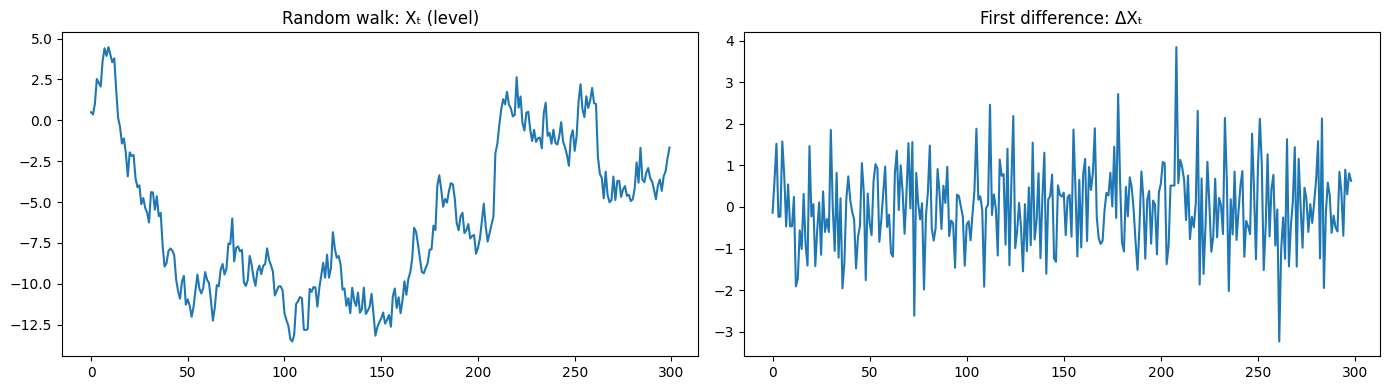

Xₜ (level)
ADF statistic : -1.9084
p-value       : 0.3281
5% critical   : -2.8713
---------------------------------------------
ΔXₜ
ADF statistic : -18.5895
p-value       : 0.0000
5% critical   : -2.8713
---------------------------------------------


/tmp/ipykernel_1443/730867180.py:12: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(pd.Series(series).dropna(), autolag="AIC")
/tmp/ipykernel_1443/730867180.py:12: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(pd.Series(series).dropna(), autolag="AIC")


In [ ]:
n=300
x=np.cumsum(np.random.normal(size=n))
dx=np.diff(x)

fig,ax=plt.subplots(1,2,figsize=(14,4))
ax[0].plot(x); ax[0].set_title("Random walk: Xₜ (level)")
ax[1].plot(dx); ax[1].set_title("First difference: ΔXₜ")
plt.tight_layout(); plt.show()

adf_result(x,"Xₜ (level)")
adf_result(dx,"ΔXₜ")


**Note:** levels can wander persistently, while first differences fluctuate around a stable mean. This is the basic intuition behind an I(1) series.

## 2. Two unrelated random walks: the spurious-regression problem

Generate two independent random walks and regress one on the other.

If the underlying processes are unrelated, any impressive-looking relationship in levels should be treated cautiously.


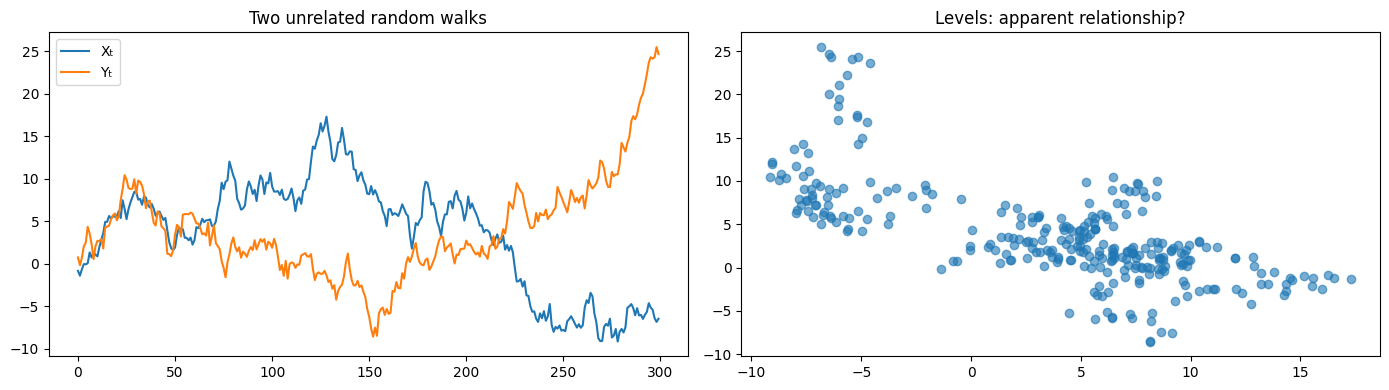

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.482
Model:                            OLS   Adj. R-squared:                  0.480
Method:                 Least Squares   F-statistic:                     277.2
Date:                Tue, 06 Oct 2026   Prob (F-statistic):           1.83e-44
Time:                        05:58:55   Log-Likelihood:                -856.59
No. Observations:                 300   AIC:                             1717.
Df Residuals:                     298   BIC:                             1725.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          6.1917      0.279     22.201      0.0

In [ ]:
x=np.cumsum(np.random.normal(size=n))
y=np.cumsum(np.random.normal(size=n))
rw=pd.DataFrame({"X":x,"Y":y})

fig,ax=plt.subplots(1,2,figsize=(14,4))
ax[0].plot(rw["X"],label="Xₜ"); ax[0].plot(rw["Y"],label="Yₜ")
ax[0].set_title("Two unrelated random walks"); ax[0].legend()
ax[1].scatter(rw["X"],rw["Y"],alpha=.6)
ax[1].set_title("Levels: apparent relationship?")
plt.tight_layout(); plt.show()

model=sm.OLS(rw["Y"],sm.add_constant(rw["X"])).fit()
print(model.summary())


### Class Question:

> If X and Y were generated independently, why can the regression still look statistically impressive?

->This is the intuition behind **spurious regression**.

## 3. Construct a cointegrated pair

Now deliberately create:

$$ X_t=X_{t-1}+v_t $$

and

$$ Y_t=1+0.8X_t+u_t, $$

where $u_t$ is stationary.

Therefore:

$$ Y_t-0.8X_t=1+u_t $$

is stationary.

That stable residual is the key to cointegration.



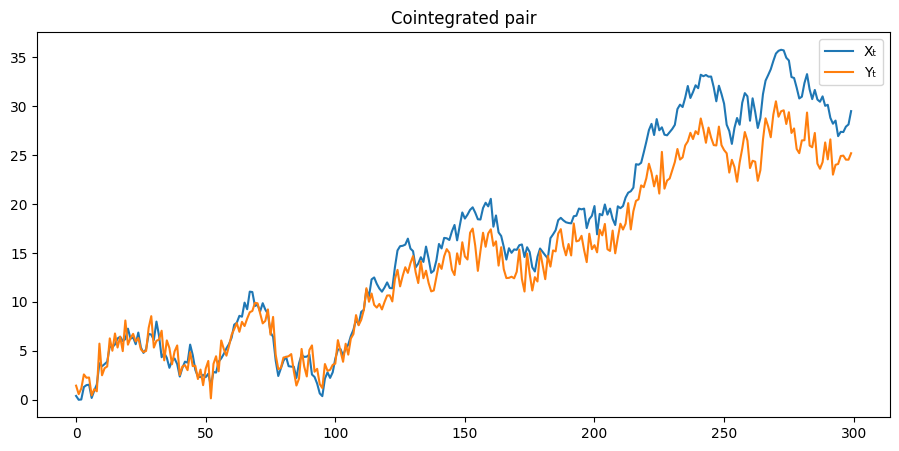

Xₜ
ADF statistic : -0.9976
p-value       : 0.7542
5% critical   : -2.8713
---------------------------------------------
Yₜ
ADF statistic : -1.0476
p-value       : 0.7355
5% critical   : -2.8713
---------------------------------------------
ΔXₜ
ADF statistic : -18.1347
p-value       : 0.0000
5% critical   : -2.8713
---------------------------------------------
ΔYₜ
ADF statistic : -17.8715
p-value       : 0.0000
5% critical   : -2.8713
---------------------------------------------


/tmp/ipykernel_1443/730867180.py:12: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(pd.Series(series).dropna(), autolag="AIC")
/tmp/ipykernel_1443/730867180.py:12: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(pd.Series(series).dropna(), autolag="AIC")
/tmp/ipykernel_1443/730867180.py:12: FutureWarning: adfuller currently returns a plain

In [ ]:
x=np.cumsum(np.random.normal(size=n))
u=np.random.normal(size=n)
y=1+0.8*x+u
coint_df=pd.DataFrame({"X":x,"Y":y})

plt.figure(figsize=(11,5))
plt.plot(coint_df["X"],label="Xₜ")
plt.plot(coint_df["Y"],label="Yₜ")
plt.title("Cointegrated pair")
plt.legend(); plt.show()

adf_result(coint_df["X"],"Xₜ")
adf_result(coint_df["Y"],"Yₜ")
adf_result(coint_df["X"].diff(),"ΔXₜ")
adf_result(coint_df["Y"].diff(),"ΔYₜ")


## 4. Engle–Granger Step 1: estimate the long-run relationship

Estimate the long-run equilibrium relationship in levels using OLS:

$$Y_t = \alpha + \beta X_t + u_t$$

Then, extract the estimated residuals ($\hat{u}_t$) to test for stationarity:

$$\hat{u}_t = Y_t - \hat{\alpha} - \hat{\beta} X_t$$


                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.986
Model:                            OLS   Adj. R-squared:                  0.986
Method:                 Least Squares   F-statistic:                 2.163e+04
Date:                Tue, 06 Oct 2026   Prob (F-statistic):          3.25e-280
Time:                        06:00:43   Log-Likelihood:                -423.94
No. Observations:                 300   AIC:                             851.9
Df Residuals:                     298   BIC:                             859.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.9922      0.105      9.461      0.0

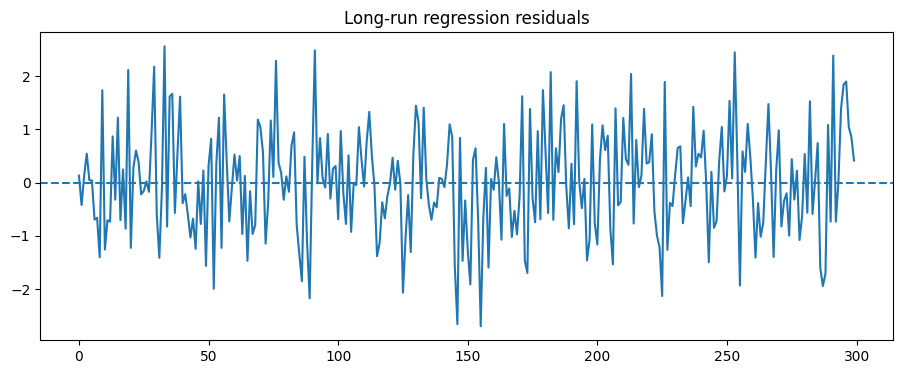

In [ ]:
lr=sm.OLS(coint_df["Y"],sm.add_constant(coint_df["X"])).fit()
print(lr.summary())

coint_df["residual"]=lr.resid
print(f"α̂ = {lr.params['const']:.4f}")
print(f"β̂ = {lr.params['X']:.4f}")

plt.figure(figsize=(11,4))
plt.plot(coint_df["residual"])
plt.axhline(0,linestyle="--")
plt.title("Long-run regression residuals")
plt.show()


## 5. Engle–Granger Step 2: test the residual

The key question is:

$$\hat{u}_t \sim I(0) \text{?}$$

If the residual is stationary, the non-stationary variables share a stable long-run relationship.



In [ ]:
adf_result(coint_df["residual"],"Long-run residual ûₜ")

stat,pvalue,crit=coint(coint_df["Y"],coint_df["X"])
print(f"Engle–Granger statistic: {stat:.4f}")
print(f"Engle–Granger p-value : {pvalue:.4f}")
print("Critical values:",crit)


Long-run residual ûₜ
ADF statistic : -16.9669
p-value       : 0.0000
5% critical   : -2.8713
---------------------------------------------
Engle–Granger statistic: -16.9954
Engle–Granger p-value : 0.0000
Critical values: [-3.93344345 -3.35664144 -3.05866504]


/tmp/ipykernel_1443/730867180.py:12: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(pd.Series(series).dropna(), autolag="AIC")


**Important:** the residual-based Engle–Granger test has its own critical values. Do not mechanically treat it as an ordinary ADF test with ordinary ADF critical values.

### Classroom takeaway

> X and Y can each be I(1), while their equilibrium error is I(0). That is cointegration.


## 6. Contrast: unrelated random walks

Repeat the same long-run regression for the unrelated random walks. If there is no stable long-run relationship, the residual should itself behave like a non-stationary process.


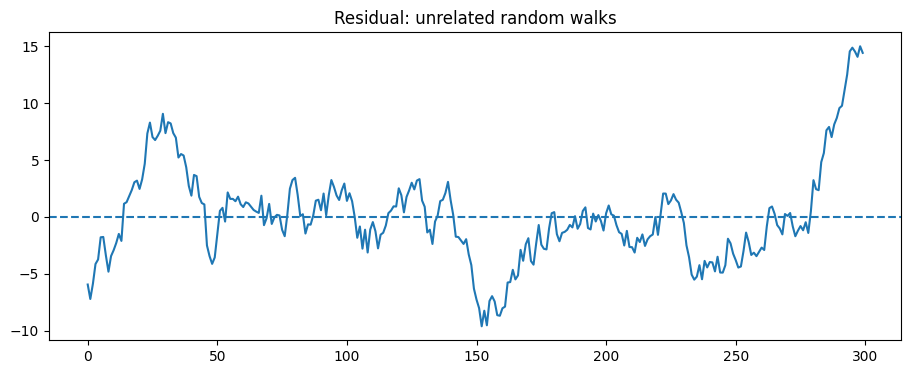

Residual from unrelated random walks
ADF statistic : -1.3507
p-value       : 0.6056
5% critical   : -2.8713
---------------------------------------------
Engle–Granger p-value: 0.8100


/tmp/ipykernel_1443/730867180.py:12: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(pd.Series(series).dropna(), autolag="AIC")


In [ ]:
rw_lr=sm.OLS(rw["Y"],sm.add_constant(rw["X"])).fit()
rw["residual"]=rw_lr.resid

plt.figure(figsize=(11,4))
plt.plot(rw["residual"])
plt.axhline(0,linestyle="--")
plt.title("Residual: unrelated random walks")
plt.show()

adf_result(rw["residual"],"Residual from unrelated random walks")
stat,pvalue,crit=coint(rw["Y"],rw["X"])
print(f"Engle–Granger p-value: {pvalue:.4f}")


### Compare visually

**Unrelated random walks:** residual keeps wandering.

**Cointegrated series:** residual fluctuates around a stable level.

This is the central visual intuition.

## 7. From cointegration to the Error Correction Model

Suppose the long-run equilibrium relationship is:

$$Y_t = \alpha + \beta X_t + u_t$$

Then, the corresponding simple **Error Correction Model (ECM)** is structured as:

$$\Delta Y_t = \gamma_0 + \gamma_1 \Delta X_t + \lambda u_{t-1} + \varepsilon_t$$

Where:
* **$\Delta X_t$**: Short-run change (shock) in $X$.
* **$u_{t-1}$**: Previous-period disequilibrium error ($Y_{t-1} - \alpha - \beta X_{t-1}$).
* **$\lambda$**: Speed of adjustment coefficient (expected to be negative, $\lambda < 0$).


In [ ]:
ecm=coint_df.copy()
ecm["dY"]=ecm["Y"].diff()
ecm["dX"]=ecm["X"].diff()
ecm["ec_lag"]=ecm["residual"].shift(1)
ecm=ecm.dropna()

ecm_model=sm.OLS(ecm["dY"],sm.add_constant(ecm[["dX","ec_lag"]])).fit()
print(ecm_model.summary())

lam=ecm_model.params["ec_lag"]
print(f"Estimated λ = {lam:.4f}")


                            OLS Regression Results                            
Dep. Variable:                     dY   R-squared:                       0.602
Model:                            OLS   Adj. R-squared:                  0.600
Method:                 Least Squares   F-statistic:                     224.3
Date:                Tue, 06 Oct 2026   Prob (F-statistic):           5.14e-60
Time:                        06:16:56   Log-Likelihood:                -422.84
No. Observations:                 299   AIC:                             851.7
Df Residuals:                     296   BIC:                             862.8
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0025      0.058      0.043      0.9

## 8. Interpreting the error-correction coefficient

If:

$$\lambda < 0$$

then the estimated adjustment is in the direction of restoring equilibrium.

For example, if $\lambda = -0.30$, a common interpretation is that about **30% of the previous period's disequilibrium is corrected during the current period**, holding the other included terms constant.

The exact interpretation depends on the model specification.



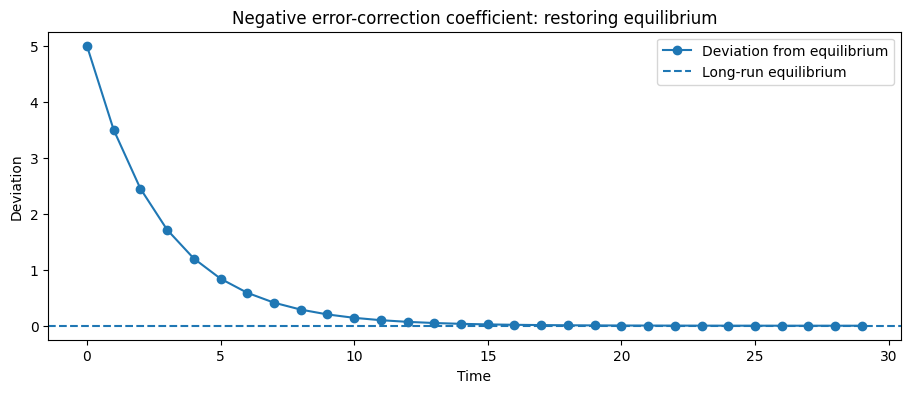

In [ ]:
# Simple visual illustration of equilibrium correction
periods=np.arange(30)
deviation=np.zeros(30)
deviation[0]=5
lam=-0.30

for t in range(1,30):
    deviation[t]=deviation[t-1]+lam*deviation[t-1]

plt.figure(figsize=(11,4))
plt.plot(periods,deviation,marker="o",label="Deviation from equilibrium")
plt.axhline(0,linestyle="--",label="Long-run equilibrium")
plt.title("Negative error-correction coefficient: restoring equilibrium")
plt.xlabel("Time"); plt.ylabel("Deviation")
plt.legend(); plt.show()


## 9. Optional real-data extension

The same workflow can be applied to a real economic pair such as:

- income and consumption;
- money supply and prices;
- expenditure and income.

For teaching and 1st time learning, the simulated example is useful because we **know how the data were generated**. Once the intuition is clear, we can replace the simulated series with a real dataset and repeat:

**levels → integration order → long-run regression → residual → cointegration test → ECM.**


# 10. Try to answer these yourself:

1. If X and Y are both I(1), are they automatically cointegrated?
2. What must be stationary for two I(1) variables to be cointegrated?
3. What does \\(\Delta X_t\\) represent in the ECM?
4. What does \\(u_{t-1}\\) represent?
5. Why is a negative \\(\lambda\\) associated with correction toward equilibrium?




### Expected answers :
1. No.
2. A suitable linear combination / equilibrium residual.
3. Short-run change in X.
4. Previous-period deviation from long-run equilibrium.
5. A positive deviation then produces a negative adjustment in the dependent variable, other things equal.

# One-line story

> **Cointegration tells us that non-stationary variables can share a stable long-run relationship; ECM tells us how short-run movements respond when the system is away from that equilibrium.**

### Board Summary

$$X_t, Y_t \sim I(1)$$

$$Y_t = \alpha + \beta X_t + u_t$$

$$\hat{u}_t \sim I(0) \quad\Rightarrow\quad \text{Cointegration}$$

$$\Delta Y_t = \gamma_0 + \gamma_1 \Delta X_t + \lambda \hat{u}_{t-1} + \varepsilon_t$$

